# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df =pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
De las variables numéricas, solo una requiere cambio:

* `edad` — está como `float64` pero debería ser `int64` ya que representa años enteros.

**Variables binarias**  
Las variables binarias que requieren cambio son:

* `miembro_premium` — está como `int64` pero representa una categoría binaria (0/1), debería convertirse a `bool` o `category`.
* `abandono` — mismo caso, `int64` representando (0/1), debería convertirse a `bool` o `category`.
Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Las variables categóricas que requieren cambio son:

* `tipo_dispositivo` — está como `object` pero tiene valores fijos (móvil, escritorio, tablet); debería convertirse a `category`.
* `region` — mismo caso, `object` con valores fijos (norte, sur, oeste, este); debería convertirse a `category`.

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype(int)
df['miembro_premium'] = df['miembro_premium'].astype(bool)
df['abandono'] = df['abandono'].astype(bool)
df['tipo_dispositivo'] = df['tipo_dispositivo'].astype('category')
df['region'] = df['region'].astype('category')

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   id_cliente                 15000 non-null  object  
 1   edad                       15000 non-null  int64   
 2   nivel_ingreso              15000 non-null  float64 
 3   visitas_mes                15000 non-null  int64   
 4   compras_mes                15000 non-null  int64   
 5   gasto_publicidad_dirigida  15000 non-null  float64 
 6   satisfaccion               15000 non-null  float64 
 7   miembro_premium            15000 non-null  bool    
 8   abandono                   15000 non-null  bool    
 9   tipo_dispositivo           15000 non-null  category
 10  region                     15000 non-null  category
 11  ingreso_anual              15000 non-null  float64 
dtypes: bool(2), category(2), float64(4), int64(3), object(1)
memory usage: 996.5+ KB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
df.select_dtypes(include=['float64', 'int64']).describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000




**`edad`**
- Rango de 18 a 75 años, media de 38. La mediana (38) y la media son casi idénticas, lo que sugiere una distribución simétrica sin sesgo notable.

**`nivel_ingreso`**
- Media de 30,019 muy cercana a la mediana (30,023), distribución bastante simétrica a pesar de la alta desviación estándar (9,833).

**`visitas_mes`**
- Media y mediana de 10 visitas. La std de apenas 3.15 indica que la mayoría de clientes visita con frecuencia muy similar — comportamiento homogéneo.

**`compras_mes`**
- ⚠️ El percentil 25% es 0, lo que significa que **al menos 25% de los clientes no realizó ninguna compra** en el mes a pesar de visitar la plataforma.

**`gasto_publicidad_dirigida`**
- El mínimo es 0.00, lo que indica que **hay clientes que no reciben ninguna inversión publicitaria**, lo cual podría estar relacionado con mayor abandono.

**`satisfaccion`**
- Escala del 1 al 5 con media de 3.6 y baja dispersión (std = 0.68). Los clientes se concentran en valores medios — **nadie está muy insatisfecho ni muy satisfecho**.

**`ingreso_anual`**
- ⚠️ El percentil 25% es 0.00, lo que indica que **al menos 25% de los clientes no genera ningún ingreso** para la empresa, muy probablemente asociado a `abandono = 1`.

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
df[['miembro_premium', 'abandono']].nunique()

miembro_premium    2
abandono           2
dtype: int64



Diagnóstico inicial de variables binarias

- miembro_premium — Confirmado con exactamente 2 valores únicos (0 y 1), lo que valida que no hay categorías inesperadas o errores de captura.

- abandono — Igualmente confirmado con 2 valores únicos (0 y 1), garantizando que la variable objetivo está limpia y lista para análisis.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
df[['tipo_dispositivo', 'region']].nunique()

tipo_dispositivo    3
region              4
dtype: int64

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
for col in ['tipo_dispositivo', 'region']:
    print(f"\n{col}:")
    print(df[col].value_counts())


tipo_dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

region:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64



Diagnóstico inicial de variables categóricas

- tipo_dispositivo — Presenta 3 categorías (móvil, escritorio, tablet). ⚠️ Distribución muy desbalanceada: móvil concentra el 65% de los registros (9,818), lo que podría sesgar cualquier análisis segmentado por dispositivo.
  
- region — Presenta 4 categorías (norte, oeste, sur, este). Distribución relativamente equilibrada entre regiones, siendo norte la más frecuente (4,395) y este la menor (3,069), sin representar un desbalance crítico.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

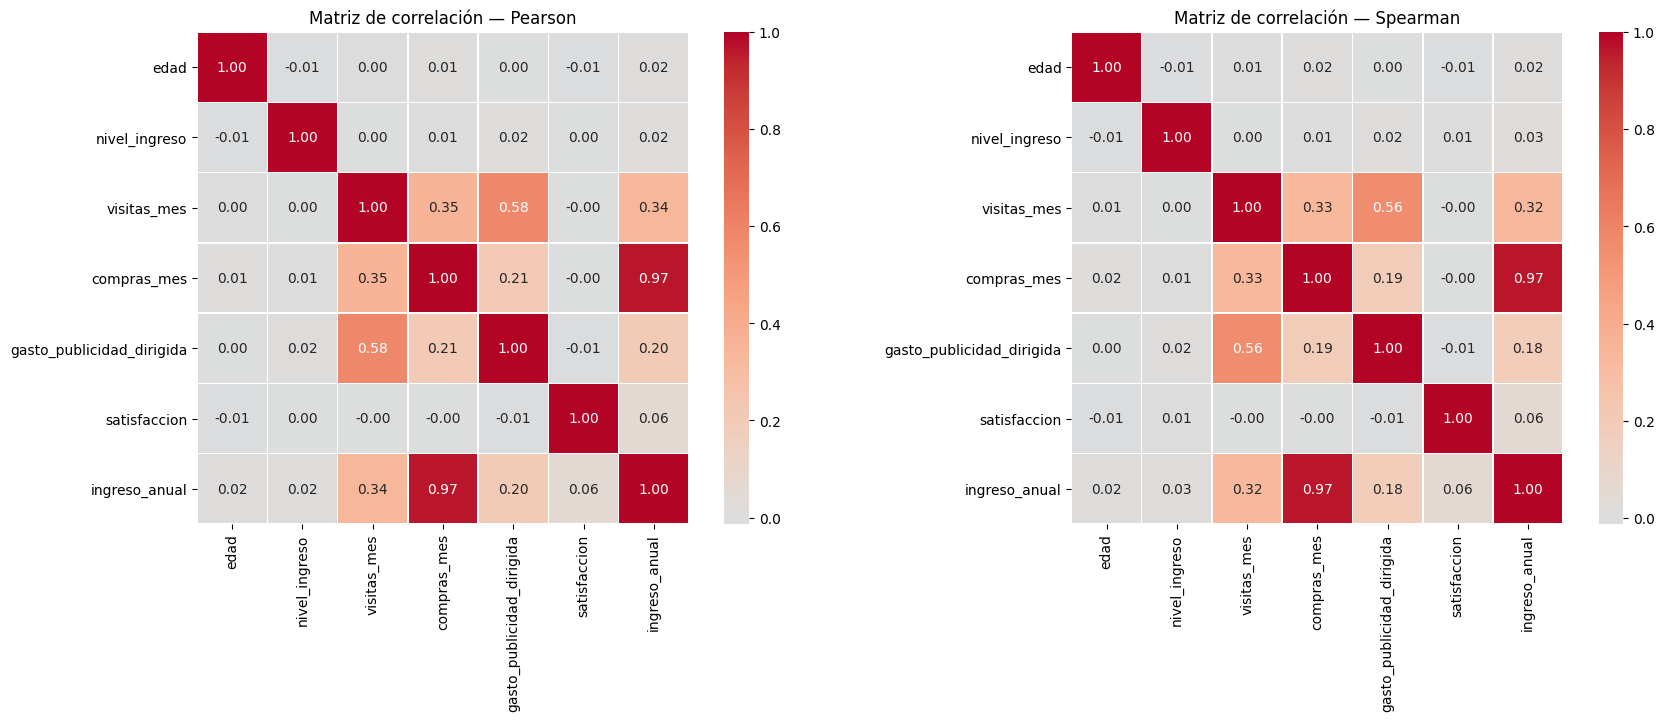

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
numericas = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes',
             'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']

corr_pearson = df[numericas].corr(method='pearson')
corr_spearman = df[numericas].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title('Matriz de correlación — Pearson')

sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=axes[1])
axes[1].set_title('Matriz de correlación — Spearman')

plt.tight_layout()
plt.show()


Observaciones generales (Heatmap)  
- Se observa que ambas matrices (Pearson y Spearman) son muy consistentes entre sí, lo que indica que las relaciones no dependen de supuestos de normalidad. La mayoría de las correlaciones son cercanas a 0, sugiriendo que las variables son en gran medida independientes entre sí, con excepción de algunos pares clave.


Observaciones respecto a `ingreso_anual`  
- Presenta una correlación muy fuerte con compras_mes (0.97 en ambos métodos), lo que indica que el ingreso generado depende casi directamente del número de compras realizadas en el mes.
  
- Muestra una correlación moderada con visitas_mes (0.34 Pearson / 0.32 Spearman), sugiriendo que a más visitas, mayor tendencia a generar ingreso, aunque la relación no es tan determinante como las compras.

  
- Su correlación con gasto_publicidad_dirigida es débil (0.20 Pearson / 0.18 Spearman), lo que cuestiona la efectividad directa de la publicidad sobre el ingreso generado.
  
- satisfaccion, edad y nivel_ingreso muestran correlaciones prácticamente nulas con ingreso_anual, lo que indica que estas variables por sí solas no explican el ingreso generado para la empresa.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.
  - No es necesario generar un scatterplot general.

La matriz de correlación ya reveló que la mayoría de las variables tienen correlaciones cercanas a 0, por lo que un scatterplot general no aportaría información adicional relevante.
El único par que justificaría un scatterplot es compras_mes vs ingreso_anual (r = 0.97), dado que su correlación casi perfecta ya es suficientemente clara desde el heatmap y no requiere visualización adicional para confirmarse.

### Scatterplot para pares clave

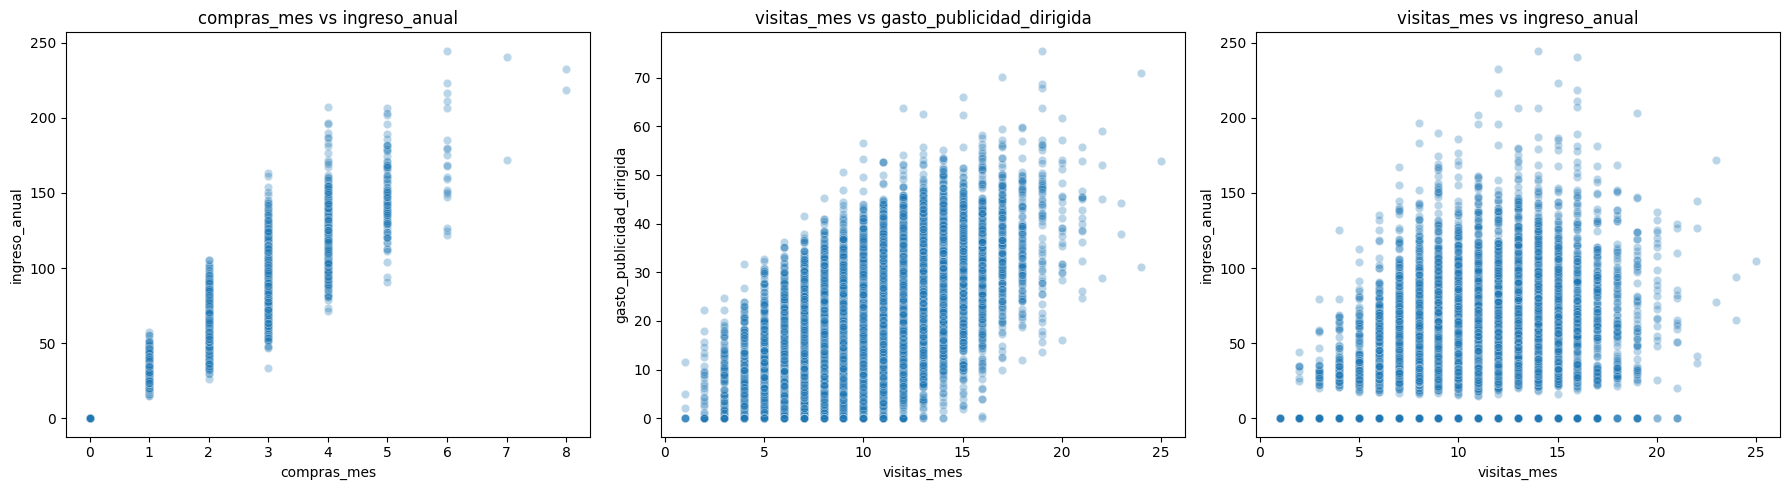

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes
pares = [
    ('compras_mes', 'ingreso_anual'),
    ('visitas_mes', 'gasto_publicidad_dirigida'),
    ('visitas_mes', 'ingreso_anual')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (x, y) in zip(axes, pares):
    sns.scatterplot(data=df, x=x, y=y, alpha=0.3, ax=ax)
    ax.set_title(f'{x} vs {y}')
    ax.set_xlabel(x)
    ax.set_ylabel(y)

plt.tight_layout()
plt.show()



 **Observaciones iniciales (Scatterplot)**

**`compras_mes` vs `ingreso_anual`**
* Dirección — positiva: a mayor número de compras, mayor ingreso anual.
* Dispersión — baja: los puntos se agrupan en columnas muy definidas por cada valor entero de compras, con poca variabilidad vertical dentro de cada grupo.
* Outliers — presencia leve en valores altos de compras (6–8), donde algunos puntos alcanzan ingresos superiores a 200.
* Colinealidad — ⚠️ muy probable: correlación de 0.97 sugiere que `compras_mes` e `ingreso_anual` son prácticamente la misma señal; usar ambas en un modelo generaría colinealidad severa.

**`visitas_mes` vs `gasto_publicidad_dirigida`**
* Dirección — positiva: a mayor número de visitas, mayor gasto publicitario asignado.
* Dispersión — alta: especialmente en rangos medios y altos de visitas (10–25), donde el gasto se dispersa ampliamente entre 0 y 75.
* Outliers — algunos puntos aislados con gasto muy alto (>60) en visitas medias (10–15).
* Colinealidad — moderada (0.58): existe asociación pero no suficiente para descartarlas como variables independientes en un modelo.

**`visitas_mes` vs `ingreso_anual`**
* Dirección — positiva débil: ligera tendencia ascendente pero con altísima dispersión.
* Dispersión — alta: banda densa en `ingreso_anual = 0` a lo largo de todos los niveles de visitas, lo que diluye cualquier tendencia.
* Outliers — presencia de valores altos de ingreso (>150) en rangos medios de visitas (8–15), sin un patrón claro.
* Colinealidad — no representa riesgo (0.34): la relación es demasiado débil para considerarlas colineales.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes
from scipy.stats import pearsonr

pares = [
    ('compras_mes', 'ingreso_anual'),
    ('visitas_mes', 'gasto_publicidad_dirigida'),
    ('visitas_mes', 'ingreso_anual')
]

for x, y in pares:
    r, p = pearsonr(df[x], df[y])
    print(f"Pearson | {x} vs {y}: r = {r:.4f}, p = {p:.4f}")

Pearson | compras_mes vs ingreso_anual: r = 0.9671, p = 0.0000
Pearson | visitas_mes vs gasto_publicidad_dirigida: r = 0.5789, p = 0.0000
Pearson | visitas_mes vs ingreso_anual: r = 0.3371, p = 0.0000


In [ ]:
# Calcular correlación entre variables relevantes
from scipy.stats import spearmanr

for x, y in pares:
    r, p = spearmanr(df[x], df[y])
    print(f"Spearman | {x} vs {y}: r = {r:.4f}, p = {p:.4f}")

Spearman | compras_mes vs ingreso_anual: r = 0.9675, p = 0.0000
Spearman | visitas_mes vs gasto_publicidad_dirigida: r = 0.5593, p = 0.0000
Spearman | visitas_mes vs ingreso_anual: r = 0.3210, p = 0.0000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


**Observaciones de correlación
compras_mes vs ingreso_anual**

Correlación positiva muy fuerte (Pearson r = 0.9671, Spearman r = 0.9675), estadísticamente significativa (p = 0.0000). Ambos métodos coinciden, lo que confirma una relación robusta y consistente.
⚠️ Colinealidad severa: con r > 0.96, usar ambas variables simultáneamente en un modelo predictivo introduciría multicolinealidad crítica. Se recomienda excluir una de ellas.

**visitas_mes vs gasto_publicidad_dirigida**

Correlación positiva moderada (Pearson r = 0.5789, Spearman r = 0.5593), estadísticamente significativa (p = 0.0000). La ligera diferencia entre ambos métodos sugiere una relación con componente no lineal.
Colinealidad moderada: no representa un riesgo crítico en un modelo, pero debe monitorearse si ambas variables se incluyen juntas.

**visitas_mes vs ingreso_anual**

Correlación positiva débil (Pearson r = 0.3371, Spearman r = 0.3210), estadísticamente significativa (p = 0.0000). La baja magnitud indica que las visitas por sí solas no son un predictor confiable del ingreso.
Sin riesgo de colinealidad: la relación es demasiado débil para representar un problema en modelos posteriores.

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

binarias = ['miembro_premium', 'abandono']
numericas = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes',
             'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']

for b in binarias:
    for n in numericas:
        r, p = pointbiserialr(df[b].astype(int), df[n])
        print(f"Punto biserial | {b} vs {n}: r = {r:.4f}, p = {p:.4f}")
    print()

Punto biserial | miembro_premium vs edad: r = 0.0046, p = 0.5728
Punto biserial | miembro_premium vs nivel_ingreso: r = -0.0056, p = 0.4930
Punto biserial | miembro_premium vs visitas_mes: r = -0.0127, p = 0.1211
Punto biserial | miembro_premium vs compras_mes: r = 0.0034, p = 0.6744
Punto biserial | miembro_premium vs gasto_publicidad_dirigida: r = 0.0027, p = 0.7390
Punto biserial | miembro_premium vs satisfaccion: r = 0.0257, p = 0.0016
Punto biserial | miembro_premium vs ingreso_anual: r = 0.0931, p = 0.0000

Punto biserial | abandono vs edad: r = -0.0115, p = 0.1590
Punto biserial | abandono vs nivel_ingreso: r = 0.0059, p = 0.4722
Punto biserial | abandono vs visitas_mes: r = -0.0089, p = 0.2734
Punto biserial | abandono vs compras_mes: r = 0.0083, p = 0.3099
Punto biserial | abandono vs gasto_publicidad_dirigida: r = -0.0046, p = 0.5744
Punto biserial | abandono vs satisfaccion: r = -0.0238, p = 0.0035
Punto biserial | abandono vs ingreso_anual: r = -0.0028, p = 0.7295



In [ ]:
#correlaciones mas relevantes
resultados = []
for b in binarias:
    for n in numericas:
        r, p = pointbiserialr(df[b].astype(int), df[n])
        resultados.append({'variable_binaria': b, 'variable_numerica': n, 'correlacion': round(r, 4), 'p_valor': round(p, 4)})

df_biserial = pd.DataFrame(resultados)
df_biserial[df_biserial['p_valor'] < 0.05].sort_values('correlacion', key=abs, ascending=False)

,variable_binaria,variable_numerica,correlacion,p_valor
6,miembro_premium,ingreso_anual,0.0931,0.0000
5,miembro_premium,satisfaccion,0.0257,0.0016
12,abandono,satisfaccion,-0.0238,0.0035




**Observaciones Punto-biserial**

**`miembro_premium` vs `ingreso_anual`**
* Relación positiva débil (r = 0.0931, p = 0.0000) — estadísticamente significativa. Los clientes premium tienden a generar ligeramente más ingreso anual, aunque la magnitud es baja y explica menos del 1% de la varianza.

**`miembro_premium` vs `satisfaccion`**
* Relación positiva muy débil (r = 0.0257, p = 0.0016) — estadísticamente significativa pero prácticamente irrelevante en magnitud. Ser miembro premium no garantiza mayor satisfacción.

**`abandono` vs `satisfaccion`**
* Relación negativa muy débil (r = -0.0238, p = 0.0035) — estadísticamente significativa. Clientes que abandonaron tienden a reportar satisfacción ligeramente menor, aunque el efecto es mínimo y no permite usar `satisfaccion` como predictor confiable de abandono.

### V de Cramér

In [ ]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(tabla)
    n = tabla.sum().sum()
    r, k = tabla.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

In [ ]:
# Aplicar V de Cramér en variables relevantes

categoricas = ['tipo_dispositivo', 'region', 'miembro_premium', 'abandono']

for i in range(len(categoricas)):
    for j in range(i + 1, len(categoricas)):
        v = cramers_v(df[categoricas[i]], df[categoricas[j]])
        print(f"Cramér V | {categoricas[i]} vs {categoricas[j]}: V = {v:.4f}")

Cramér V | tipo_dispositivo vs region: V = 0.0124
Cramér V | tipo_dispositivo vs miembro_premium: V = 0.0197
Cramér V | tipo_dispositivo vs abandono: V = 0.0072
Cramér V | region vs miembro_premium: V = 0.0126
Cramér V | region vs abandono: V = 0.0154
Cramér V | miembro_premium vs abandono: V = 0.1202



**Observaciones V de Cramér**

- tipo_dispositivo vs region (V = 0.0124) — asociación prácticamente nula. El tipo de dispositivo usado no depende de la región geográfica del cliente.

- tipo_dispositivo vs miembro_premium (V = 0.0197) — asociación prácticamente nula. Ser miembro premium no está relacionado con el dispositivo utilizado.

  
- tipo_dispositivo vs abandono (V = 0.0072) — asociación prácticamente nula. El abandono no está influenciado por el tipo de dispositivo.

  
- region vs miembro_premium (V = 0.0126) — asociación prácticamente nula. La membresía premium se distribuye de forma independiente a la región.

  
- region vs abandono (V = 0.0154) — asociación prácticamente nula. El abandono ocurre de forma similar en todas las regiones.

  
- miembro_premium vs abandono (V = 0.1202) — ⚠️ es la asociación más fuerte del grupo, aunque sigue siendo débil. Existe una ligera tendencia entre el estatus de    membresía y el abandono, lo que sugiere que los clientes premium abandonan en proporciones ligeramente distintas a los no premium.

## Sección 5 - Interpretación de resultados para el negocio


### Hallazgo 1 —
**El ingreso anual está casi determinado por el número de compras mensuales**
- Evidencia visual: Scatterplot de compras_mes vs ingreso_anual muestra una estructura escalonada muy definida, donde cada nivel de compras corresponde a un rango de ingreso claramente superior al anterior.
  
- Evidencia numérica: Pearson r = 0.9671, Spearman r = 0.9675, p = 0.0000 en ambos métodos.

- Interpretación: Existe una asociación positiva casi perfecta entre el número de compras realizadas en el mes y el ingreso anual generado. Ambos coeficientes son consistentes, lo que confirma que la relación es robusta y no depende de supuestos de normalidad.

- No podemos afirmar: Que aumentar las compras cause directamente un mayor ingreso anual. Podrían existir factores intermedios no capturados en el dataset que expliquen ambas variables simultáneamente.


- Implicación de negocio: El número de compras mensuales es el indicador más fuerte del valor económico de un cliente. Estrategias orientadas a incrementar la frecuencia de compra podrían tener un impacto directo y medible en el ingreso generado.

### Hallazgo 2 —
***La publicidad dirigida se asigna en mayor medida a clientes con más visitas***

  
- Evidencia visual: Scatterplot de visitas_mes vs gasto_publicidad_dirigida muestra un patrón en abanico: a mayor número de visitas, mayor dispersión y nivel del gasto publicitario asignado.

- Evidencia numérica: Pearson r = 0.5789, Spearman r = 0.5593, p = 0.0000 en ambos métodos.

- Interpretación: Existe una asociación positiva moderada entre las visitas mensuales y el gasto en publicidad dirigida. La diferencia entre Pearson y Spearman sugiere que la relación tiene un componente no lineal.

- No podemos afirmar: Que asignar más gasto publicitario a clientes frecuentes cause un aumento en visitas, ni que esta estrategia de asignación sea la óptima para maximizar el ingreso.

- Implicación de negocio: La inversión publicitaria parece concentrarse en clientes ya activos. Sería valioso evaluar si redirigir parte del presupuesto hacia clientes con pocas visitas podría reactivar su comportamiento y ampliar la base generadora de ingreso.

### Hallazgo 3 —
**Las variables categóricas y binarias no muestran asociaciones relevantes entre sí**

- Evidencia visual: No aplica — no se generaron visualizaciones para estas asociaciones dado que los coeficientes no lo justificaban.

- Evidencia numérica: Todos los valores de Cramér's V son menores a 0.02, excepto miembro_premium vs abandono (V = 0.1202). Todas las correlaciones punto-biserial son menores a 0.10.

- Interpretación: Las variables categóricas (tipo_dispositivo, region) son prácticamente independientes entre sí y respecto a las variables binarias. La única asociación débil destacable es entre miembro_premium y abandono, sugiriendo que el estatus de membresía tiene una ligera relación con la probabilidad de abandonar la plataforma.

- No podemos afirmar: Que ser miembro premium reduzca o incremente causalmente el abandono. La asociación es débil y podría estar mediada por otras variables no analizadas.

- Implicación de negocio: La región y el tipo de dispositivo no deberían ser criterios prioritarios para segmentar estrategias de retención. Sin embargo, vale la pena investigar más a fondo la relación entre membresía premium y abandono, ya que podría revelar oportunidades de mejora en el programa de fidelización.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
Correlación ≠ causalidad: ninguna de las asociaciones identificadas permite establecer relaciones de causa y efecto entre variables.

El análisis se limita a relaciones lineales y monótonas; patrones no lineales complejos podrían no haber sido capturados con los coeficientes utilizados.

Las variables binarias y categóricas mostraron asociaciones muy débiles con el ingreso anual, lo que sugiere que existen factores explicativos relevantes no incluidos en el dataset.

### **Próximos pasos**

Probar segmentación adicional

Analizar el comportamiento de ingreso_anual segmentado por miembro_premium y abandono de forma conjunta para identificar perfiles de cliente de alto valor.
Explorar interacciones entre visitas_mes, compras_mes y gasto_publicidad_dirigida para detectar combinaciones que maximicen el ingreso.

Construir un modelo predictivo

Desarrollar un modelo de regresión utilizando compras_mes, visitas_mes y gasto_publicidad_dirigida como predictores principales de ingreso_anual.

Profundizar en el análisis de abandono

Aplicar técnicas de análisis multivariado para identificar qué combinación de variables está más asociada con abandono = 1, dado que ninguna variable individual mostró una correlación relevante con esta columna.